### Statement ###

Solving the problem

$$\begin{align*}
    -k \nabla u &= v\\
    \nabla \cdot v &= 0 \\

    u &= g_D \qquad             &\text{on } \Gamma_D\\
    v &= h = (h_1,\,h_2) \qquad &\text{on } \Gamma_N,
\end{align*}
$$

where $k$ is assumed piecewise smooth. The boundary conditions of $v = (v_1,\,v_2)$ on $\Gamma_N$ then translate to 

$$ \begin{align*}
    \partial_x u &= h_1 \\
    \partial_y u &= h_2
\end{align*}
$$

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append('../..')

from src import train, utils
import src.data.cube_domain as cb
import src.models.expert_discontinuous as ed
import src.models.mlp_model as mm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]

In [14]:
def k(x: torch.Tensor) -> torch.Tensor:
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 2).unsqueeze(1)


def g_D(x: torch.Tensor) -> torch.Tensor:
    return torch.column_stack([0.5 * (x[:, 0] + 1), torch.zeros_like(x[:, 0])])


def u_0(x: torch.Tensor) -> torch.Tensor:
    return torch.column_stack([1 - x[:, 0]**2, torch.zeros_like(x[:, 0])])

def v_0(x: torch.Tensor) -> torch.Tensor:
    return torch.column_stack([torch.ones_like(x[:, 1]), 1 - x[:, 1]**2])


def h(x: torch.Tensor) -> torch.Tensor:
    return torch.column_stack([torch.zeros_like(x[:, 1]), -x[:, 1] * (x[:, 0]**2 - 1)])

In [15]:
def res(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]
    
    res_1 = k(pde_in) * grad_u + v
    
    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]), create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]), create_graph=True)[0][:, 1]

    res_2 = v_1_x + v_2_y
    
    return res_1, res_2

In [16]:
def chi(x):
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 0).to(torch.float16).unsqueeze(1)

model_ctx_u = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(g_D, u_0),
    last_layer_activation='disc',
    disc_steepness=10.0 
)

model_ctx_v = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(h, v_0),
    last_layer_activation='disc',
    disc_steepness=10.0
)



model_u = mm.MLPModel(model_ctx_u).to(device)
optim_u = torch.optim.Adam(model_u.parameters(), lr=5e-4)
scheduler_u = ReduceLROnPlateau(optim_u, factor=0.75, patience=3_000)

model_v = mm.MLPModel(model_ctx_v).to(device)
#model_v.load_state_dict(model_u.state_dict())
optim_v = torch.optim.Adam(model_v.parameters(), lr=5e-4)
scheduler_v = ReduceLROnPlateau(optim_v, factor=0.75, patience=3_000)

In [ ]:

def loss_u(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)

    u_out = model(pde_in)
    
    param_flags = [p.requires_grad for p in model_v.parameters()]
    for par in model_v.parameters():
        par.requires_grad = False
    
    v_out = model_v(pde_in)

    for par, flag in zip(model_v.parameters(), param_flags):
        par.requires_grad = flag
        
    res_1, res_2 = res(u_out, v_out, pde_in)

    loss_1 = torch.mean(res_1[:, 0]**2 + res_1[:, 1]**2)

    return [loss_1]

L1 = 100
L2 = 1

def loss_v(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)
    
    param_flags = [p.requires_grad for p in model_u.parameters()]
    for par in model_u.parameters():
        par.requires_grad = False
    
    u_out = model_u(pde_in)
    
    for par, flag in zip(model_u.parameters(), param_flags):
        par.requires_grad = flag
        
    v_out = model(pde_in)
    
    res_1, res_2 = res(u_out, v_out, pde_in)
    
    loss_1 = torch.mean(res_1[:, 0]**2 + res_1[:, 1]**2)
    loss_2 = torch.mean(res_2**2)

    return [loss_1, 10 * loss_2]

In [18]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=2_000,
    N_sides=[(0, 0), (0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)

In [19]:
train_ctx_u = train.TrainingContext(
    model=model_u,
    domain=domain,
    optimizer=optim_u,
    loss_fn=loss_u,
    epochs=200,
    monitor_gradient=True,
    monitor_lr=True,
    scheduler=scheduler_u,
)

train_ctx_v = train.TrainingContext(
    model=model_v,
    domain=domain,
    optimizer=optim_v,
    loss_fn=loss_v,
    epochs=200,
    monitor_gradient=True,
    monitor_lr=True,
    scheduler=scheduler_v
)

CYCLES = 300

v_loss = []
u_loss = []
v_loss_comp = [[], []]


for cycle in range(CYCLES):
    print(f"Starting cycle {cycle}/{CYCLES}")
    print("Training v, holding u const...")
    model_u.eval()
    model_v.train()
   # _, _ = train.train_switch_to_lbfgs(train_ctx_v, epochs_with_lbfgs=300, lbfgs_lr=0.1)
    v_loss_temp, v_comp_loss_temp = train.simple_train(train_ctx_v)
    print("Training u, holding v const...")
    model_v.eval()
    model_u.train()
   # _, _ = train.train_switch_to_lbfgs(train_ctx_u, epochs_with_lbfgs=300, lbfgs_lr=0.1)
    u_loss_temp, _ = train.simple_train(train_ctx_u)
    
    v_loss += v_loss_temp
    u_loss += u_loss_temp
    
    v_loss_comp[0] += v_comp_loss_temp[0]
    v_loss_comp[1] += v_comp_loss_temp[1]
    

print("Switching to LBFGS cycles")

Starting cycle 0/300
Training v, holding u const...
Loss at epoch 1 is: 131.6956024169922. Total gradient norm: inf Current learing rate: 0.0005 
Loss at epoch 100 is: 13.922266006469727. Total gradient norm: 11.05303080172905 Current learing rate: 0.0005 
Loss at epoch 200 is: 12.83299446105957. Total gradient norm: 5.195431710325329 Current learing rate: 0.0005 
Training u, holding v const...
Loss at epoch 1 is: 0.11156869679689407. Total gradient norm: 0.1726923353981678 Current learing rate: 0.0005 
Loss at epoch 100 is: 0.07879579812288284. Total gradient norm: 0.03574265690273068 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.07498752325773239. Total gradient norm: 0.059821181956300734 Current learing rate: 0.0005 
Starting cycle 1/300
Training v, holding u const...
Loss at epoch 1 is: 8.615730285644531. Total gradient norm: inf Current learing rate: 0.0005 
Loss at epoch 100 is: 7.383418560028076. Total gradient norm: 3.094499408227287 Current learing rate: 0.0005 


KeyboardInterrupt: 

/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/libtorch_1745854776362/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


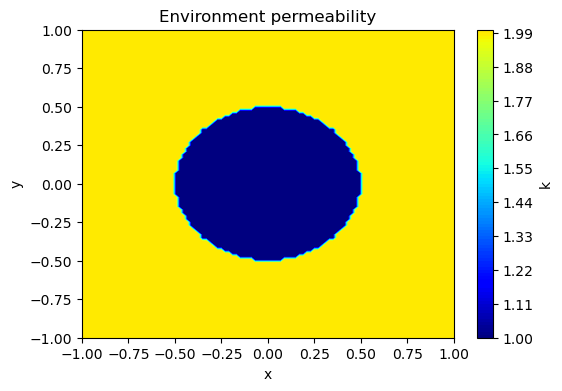

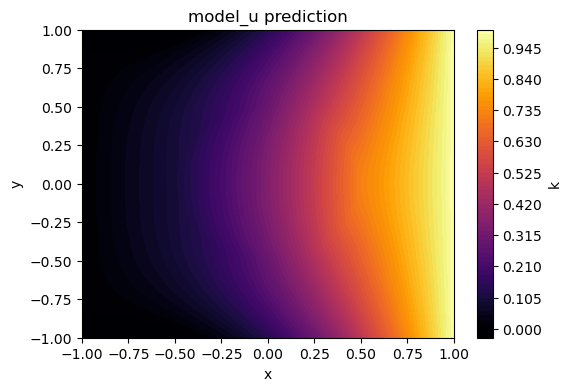

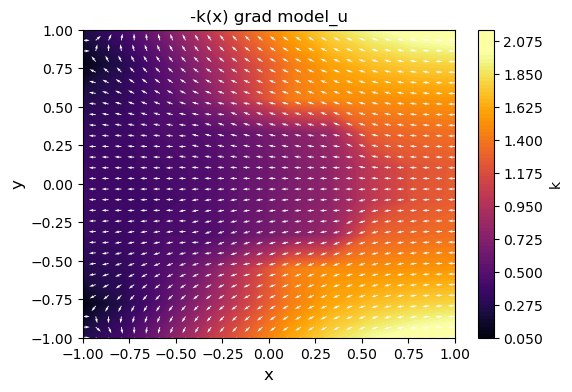

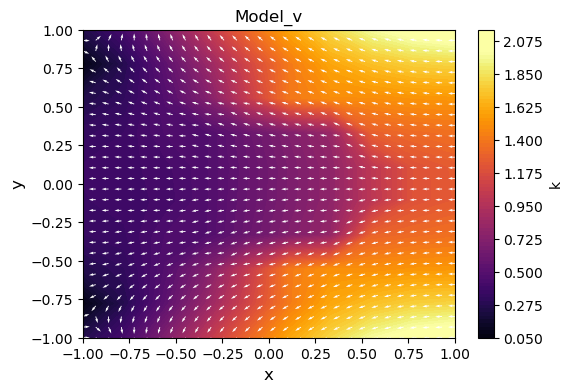

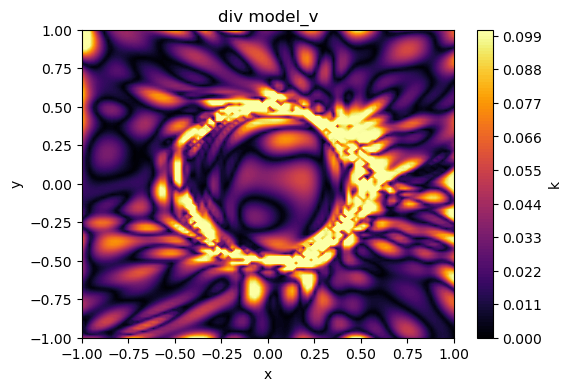

In [ ]:
def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    u = model(pde_input)
    u_grad = grad(u, pde_input, torch.ones_like(u), create_graph=True)[0]
    u_grad = -1 * k(pde_input) * u_grad
    u_x, u_y = u_grad[:, 0], u_grad[:, 1]
    
    u_xx = grad(u_x, pde_input, torch.ones_like(u_x), create_graph=True)[0][:, 0]
    u_yy = grad(u_y, pde_input, torch.ones_like(u_y), create_graph=True)[0][:, 1]

    return u_xx + u_yy

plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=["Environment permeability"],
    function_names=["k"],
    colour_map='jet',
    vmin=1,
    vmax=2.5,
    device=device,
    N=100,
    save_img=False
)

utils.plot_function_on_2d_cube([k], plot_ctx)

plot_ctx.vmin = 0
plot_ctx.vmax = 1
plot_ctx.colour_map = 'inferno'

plot_ctx.titles = ['model_u prediction']

utils.plot_function_on_2d_cube([lambda x: model_u(x)[:, 0]], plot_ctx)

# plot_ctx.vmax = 0.1
# plot_ctx.vmin = 0.0
# plot_ctx.titles = ["Residuals laplacian"]

# utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_u)), 0.0, 0.1)], plot_ctx)

plot_ctx.vmin = 0
plot_ctx.vmax = 2

plot_ctx.titles = ['-k(x) grad model_u']

def heat_flow(x):
    x.requires_grad_(True)
    u = model_u(x)[:, 0]
    
    return - k(x) * grad(u, x, torch.ones_like(u))[0]

utils.plot_vector_field_2d([lambda x: heat_flow(x)], plot_ctx, n_heigth=30, n_width=30)

plot_ctx.titles = ['Model_v']
utils.plot_vector_field_2d([lambda x:  model_v(x)], plot_ctx, n_heigth=30, n_width=30)

plot_ctx.vmax = 0.1
plot_ctx.vmin = 0.0
plot_ctx.titles = ["Residuals trained"]

def res_plot_help(x):
    x.requires_grad_(True)
    u = model_u(x)
    v = model_v(x)
    
    res_1, res_2 = res(u, v, x)
        
    return res_2#torch.norm(res_1, dim=1)

plot_ctx.titles = ["div model_v"]
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_plot_help(x)), 0.0, 0.1)], plot_ctx)

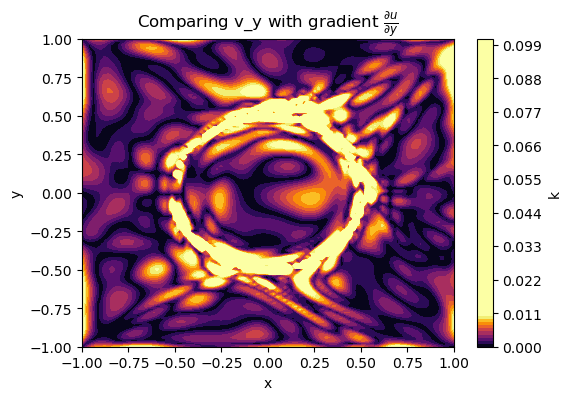

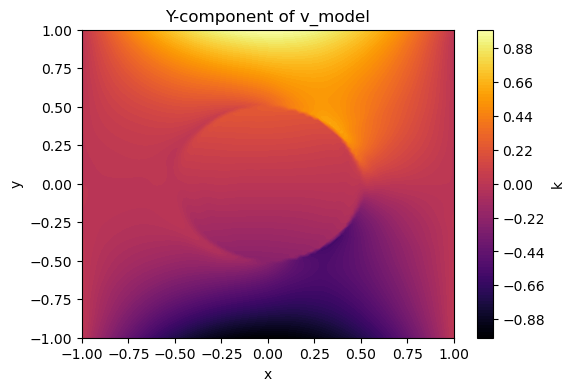

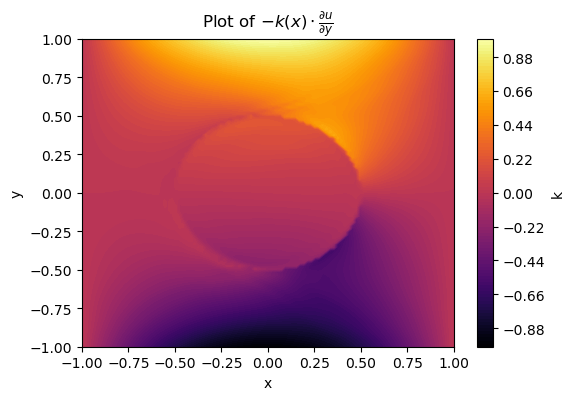

In [ ]:
def u_y_helper(x):
    x.requires_grad_(True)
    
    u = model_u(x)
    u_y = grad(u, x, torch.ones_like(u))[0][:, 1]
                
    return u_y

plot_ctx.vmax = 0.01
plot_ctx.vmin = -0
plot_ctx.titles = [r"Comparing v_y with gradient $\frac{\partial u}{\partial y}$"]

utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(k(x)[:, -1] * u_y_helper(x) + model_v(x)[:, 1]), 0.0, 0.1)], plot_ctx)

plot_ctx.vmax = 1
plot_ctx.vmin = -1
plot_ctx.titles = ["Y-component of v_model"]

utils.plot_function_on_2d_cube([lambda x: model_v(x)[:, 1]], plot_ctx)

plot_ctx.vmax = 1
plot_ctx.vmin = -1
plot_ctx.titles = [r"Plot of $-k(x)\cdot\frac{\partial u}{\partial y}$"]

utils.plot_function_on_2d_cube([lambda x: -k(x)[:, -1] * u_y_helper(x)], plot_ctx)

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


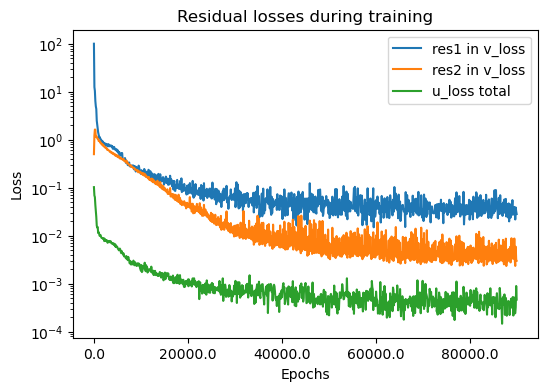

In [ ]:
plot_ctx.titles = ['Residual losses during training']
plot_ctx.y_label = 'Loss'
plot_ctx.x_label = 'Epochs'
utils.plot_loss_values({"res1 in v_loss": v_loss_comp[0], "res2 in v_loss": v_loss_comp[1], "u_loss total": u_loss}, plot_ctx)